#  Sales Data Analysis using SQLite and Python

### Introduction

In this task, we create a sales database, run SQL queries using Python, and visualize the results using charts. 
This helps us understand basic data analysis techniques using SQL, pandas, and matplotlib.


## Step1: Instaling the required libraries 

First we need to install the required libraries required according to the task in hand

In [1]:
#Installing the required libraries
!pip install pandas matplotlib

## Step 2: Create SQLite Database

We create a SQLite database `sales_data.db` and a table named `sales` with some sample data.


In [5]:
#Creating Sqlite Database
import sqlite3
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS SALES(ID INTEGER PRIMARY KEY,
PRODUCT TEXT,
QUANTITY INTEGER,
PRICE RRAL
)
''')

#Sample Data
sales_data=[
    ("Laptop", 5,700.0),
    ("Mouse", 20,25.0),
    ("Keyboard", 15,45.0),
    ("Monitor", 7,150.0),
    ("USB Cables", 5,10.0),
]

cursor.executemany("INSERT INTO SALES(PRODUCT,QUANTITY,PRICE)VALUES(?,?,?)", sales_data)
conn.commit()
conn.close()
               

##  Step 3: Connect to Database and Run SQL Query 

We use SQL to calculate total quantity sold and revenue for each product.


In [25]:
#Analyzation 
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#Step1: Connect to the Database
conn = sqlite3.connect("sales_data.db")

#Step2: SQL Query
query = """
SELECT PRODUCT, SUM(QUANTITY) AS TOTAL_QUANTITY, SUM(QUANTITY * PRICE) AS REVENUE
FROM SALES
GROUP BY PRODUCT
"""

##  Step 4: Load SQL Results into pandas

The result of the SQL query is read into a pandas DataFrame for further analysis and visualization.


In [29]:
#Loading Query Results into Pandas

df = pd.read_sql_query(query,conn)

## Step 5: Display Sales Summary

We print the summarized sales data to understand quantity and revenue by product.


In [30]:
#Print Results
print("Sales Summary:\n",df)

Sales Summary:
       PRODUCT  TOTAL_QUANTITY  REVENUE
0    Keyboard              30     1350
1      Laptop              10     7000
2     Monitor              14     2100
3       Mouse              40     1000
4  USB Cables              10      100


##  Additional Sales Insights

In this section, we extract some deeper insights from the summarized sales data:
- Top-selling product by quantity
- Highest revenue-generating product
- Average revenue per unit


In [35]:
# Top-Selling Product by Quantity
TOP_PRODUCTS = df.loc[df['TOTAL_QUANTITY'].idxmax()]
print(f"Top-Selling Product: {TOP_PRODUCTS['PRODUCT']} ({TOP_PRODUCTS['TOTAL_QUANTITY']} units sold)")


Top-Selling Product: Mouse (40 units sold)


In [36]:
# Highest Revenue Product
TOP_REVENUE = df.loc[df['REVENUE'].idxmax()]
print(f"Highest Revenue Product: {TOP_REVENUE['PRODUCT']} (${TOP_REVENUE['REVENUE']:.2f})")


Highest Revenue Product: Laptop ($7000.00)


In [37]:
# Average Revenue per Unit
df['AVERAGE_PRICE'] = df['REVENUE'] / df['TOTAL_QUANTITY']
print("Average Price per Unit for Each Product:")
print(df[['PRODUCT', 'AVERAGE_PRICE']])


Average Price per Unit for Each Product:
      PRODUCT  AVERAGE_PRICE
0    Keyboard           45.0
1      Laptop          700.0
2     Monitor          150.0
3       Mouse           25.0
4  USB Cables           10.0


##  Step 6: Visualize Revenue using Bar Chart

We plot a bar chart to show how much revenue each product has generated.


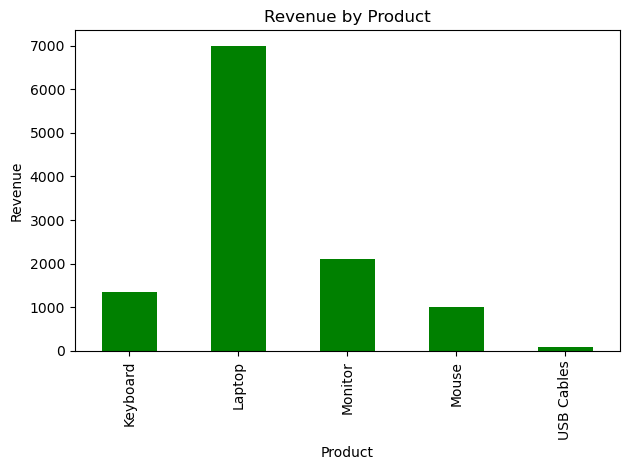

In [21]:
#Visualization
df.plot(kind= 'bar', x= 'PRODUCT', y= 'REVENUE', color = 'Green', legend= False)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

conn.close()


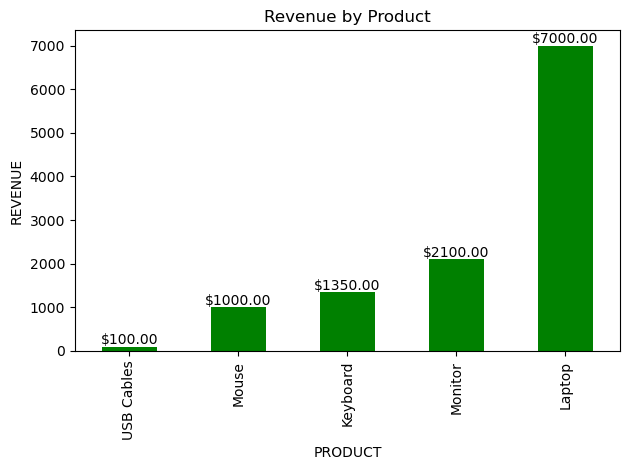

In [18]:
#Adding Value Labels on Bars
ax = df.plot(kind='bar', x='PRODUCT', y='REVENUE', color='green', legend=False)
for index, value in enumerate(df['REVENUE']):
    ax.text(index, value + 50, f"${value:.2f}", ha='center')
plt.title("Revenue by Product")
plt.ylabel("REVENUE")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()


##  Step 7: Pie Chart - Quantity Distribution by Product

A pie chart showing the percentage share of total quantity sold for each product.


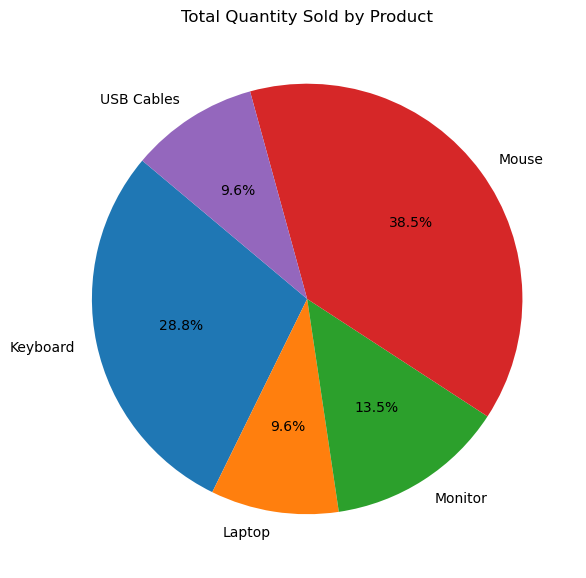

In [23]:
# Pie chart for total quantity sold
plt.figure(figsize=(6, 6))
plt.pie(df['TOTAL_QUANTITY'], labels=df['PRODUCT'], autopct='%1.1f%%', startangle=140)
plt.title("Total Quantity Sold by Product")
plt.tight_layout()
plt.savefig("quantity_pie_chart.png")
plt.show()

##  Step 8: Calculate Total Revenue

We calculate and display the total revenue generated from all products combined.


In [13]:
#Total Revenue
total = df['REVENUE'].sum()
print(f"\nTotal Revenue: S{total:2f}")


Total Revenue: S11550.000000


##  Step 9: Sort Product By Revenue

We sort products based on revenue.

In [14]:
#Sorting Product By Revenue
df = df.sort_values(by='REVENUE', ascending= True)

##  Step 10: Export Result as CSV.  

In [15]:
#Exporting Result as CSV
df.to_csv("sales_summary.csv", index=False)

## Conclusion

This notebook showcases how simple SQL queries inside Python can help summarize and visualize sales data effectively. 
We also extracted business insights such as top-performing products and average unit revenue, which are useful in real-world decision-making.
